In [1]:
import numpy as np
from matplotlib import pyplot as plt
import jax
import jax.numpy as jnp
import optax
import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

ModuleNotFoundError: No module named 'gigalens'

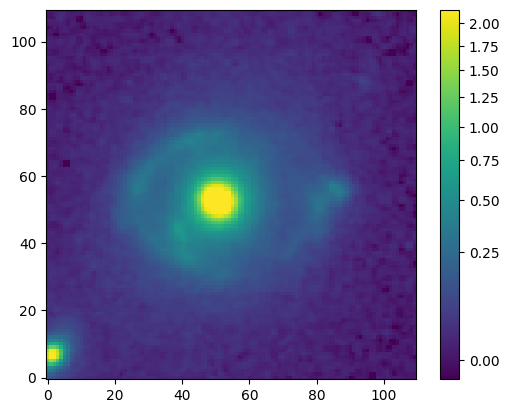

In [1]:
from astropy.io import fits
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt
import numpy as np

data94 = fits.open("final_94_drz.fits")
image94 = data94[1].data
exp_time = data94[0].header["EXPTIME"]
data94.close()
#image94[image94<0] = 0
image_size = 110
lens_x=1227
lens_y=1070
system = image94[(int)(lens_y-image_size/2):(int)(lens_y+image_size/2),(int)(lens_x-image_size/2):(int)(lens_x+image_size/2)]

norm = simple_norm(system, "sqrt", percent=99.)
plt.imshow(system, norm=norm, cmap="viridis", origin='lower')
plt.colorbar()

epsf = np.load("psf.npy")


In [ ]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.5), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(-0.3, 0.15),
                center_y=tfd.Normal(-0.1, 0.15),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.15), gamma2=tfd.Normal(0, 0.15))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(2, 6),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(-0.3, 0.05),
                center_y=tfd.Normal(-0.1, 0.05),
                Ie=tfd.LogNormal(jnp.log(30), 0.5),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(4, 8),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(-0.3, 0.05),
                center_y=tfd.Normal(-0.1, 0.05),
                Ie=tfd.LogNormal(jnp.log(30), 0.5),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(24, 28),
                e1=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                center_x=tfd.Normal(-3.4, 0.25),
                center_y=tfd.Normal(-3.1, 0.25),
                Ie=tfd.LogNormal(jnp.log(30), 0.5),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(-0.2, 0.25),
                center_y=tfd.Normal(-0.2, 0.25),
                Ie=tfd.LogNormal(jnp.log(20.0), 0.5),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0.2, 0.25),
                center_y=tfd.Normal(0, 0.25),
                Ie=tfd.LogNormal(jnp.log(20.0), 0.5),
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

In [ ]:
kernel = np.array(epsf).astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=110, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False), sersic.SersicEllipse(use_lstsq=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = system
background_rms = 0.007616264 #background_rms from photutils.background
prob_model = ForwardProbModel(prior, observed_img, background_rms=background_rms, exp_time=exp_time)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [ ]:
schedule_fn = optax.polynomial_schedule(init_value=-0.02, end_value=-0.003, 
                                      power=0.1, transition_steps=1000)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
map_estimate = model_seq.MAP(opt, seed=0, num_steps=1000)

In [ ]:
lps = prob_model.log_prob(LensSimulator(phys_model, sim_config, bs=500), map_estimate)[0]
best = map_estimate[jnp.argmax(lps)][jnp.newaxis,:]

In [ ]:
physical = prob_model.bij.forward(list(best.T))
print(physical)
simulated = lens_sim.simulate(physical)
plt.imshow(simulated, norm=norm, cmap="viridis", origin='lower')

In [ ]:
schedule_fn = optax.polynomial_schedule(init_value=-1e-8, end_value=-1e-6, 
                                      power=2, transition_steps=300)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
qz, loss_hist = model_seq.SVI(best, opt, n_vi=1000, num_steps=1500)

In [ ]:
plt.plot(loss_hist)

In [ ]:
samples = model_seq.HMC(qz, num_burnin_steps=250, num_results=750)

In [ ]:
rhat= tfp.mcmc.potential_scale_reduction(jnp.transpose(samples.all_states, (1,2,0,3)), independent_chain_ndims=2)
ess = tfp.mcmc.effective_sample_size(jnp.transpose(samples.all_states, (1,2,0,3)), cross_chain_dims=[1,2])
numParams = len(rhat)
for i in range(0,numParams):
    print(i, rhat[i], ess[i])

In [ ]:
smp = jnp.transpose(samples.all_states, (1, 2, 0, 3)).reshape((-1, numParams))
smp_physical = prob_model.bij.forward(list(smp.T))

def get_corner_samples(physical, key):
    """
    Key tells you lens_mass (1), lens_light (2), or source_light (3)
    """
    return_list = []

    if key == 1:
        for i in physical[0][0].keys():
            return_list.append(physical[0][0][i])
        for j in physical[0][1].keys():
            return_list.append(physical[0][1][j])

    if key == 2:
        for i in physical[1][0].keys():
            return_list.append(physical[1][0][i])

    if key == 3:
        for i in physical[2][0].keys():
            return_list.append(physical[2][0][i])
            
    return np.stack(return_list).T

mass_samps = get_corner_samples(smp_physical, 1)
median_params = [
    [
        {key: np.median(value) for key, value in d.items()}
        for d in list_of_dicts
    ]
    for list_of_dicts in smp_physical
]
import pprint
pprint.pprint(median_params)

In [ ]:
plt.style.use('default')

labels=[r'$\theta_E$', 
        r'$\gamma$', 
        r'$\epsilon_1$', 
        r'$\epsilon_2$', 
        r'$x$', r'$y$', 
        r'$\gamma_{1,ext}$', 
        r'$\gamma_{2,ext}$']

fig = corner(mass_samps, show_titles=True, title_fmt='.3f', labels=labels)
_ = fig.suptitle("Lens Parameters")

In [ ]:
simulated = lens_sim.simulate(median_params)
residual = simulated - jnp.array(system, dtype=jnp.float32)
err_map = np.sqrt(background_rms**2 + simulated/exp_time)
norm_residual = residual/err_map

fig, ax = plt.subplots(1,4, figsize=(25,4))
image_sys = ax[0].imshow(system, norm=norm, cmap="viridis", origin='lower')
image_sim = ax[1].imshow(simulated, norm=norm, cmap="viridis", origin='lower')
image_res = ax[2].imshow(residual, cmap="coolwarm", origin='lower')
image_nres = ax[3].imshow(norm_residual, cmap="coolwarm", origin='lower')
ax[0].set_title("Observed System")
ax[1].set_title("Simulated System")
ax[2].set_title("Residuals")
ax[3].set_title("Normalized Residuals")
plt.colorbar(image_res)
plt.colorbar(image_nres)
plt.show()

In [ ]:
phys_model2 = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False), sersic.SersicEllipse(use_lstsq=False), sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim2 = LensSimulator(phys_model2, sim_config, bs=1)
obj1 = median_params[:]
obj1[-1] = [median_params[-1][0]]
simulatedobj1 = lens_sim2.simulate(obj1)
obj2 = median_params[:]
obj2[-1] = [median_params[-1][1]]
simulatedobj2 = lens_sim2.simulate(obj2)
fig, ax = plt.subplots(1,2, figsize=(10,4))
simobj1 = ax[0].imshow(simulatedobj1, norm=norm, cmap="viridis", origin='lower')
simobj2 = ax[1].imshow(simulatedobj2, norm=norm, cmap="viridis", origin='lower')
ax[0].set_title("Simulated System - Object 1")
ax[1].set_title("Simulated System - Object 2")
plt.show()